In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, RocCurveDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

client = bigquery.Client(project="absenteeism-risk-platform")

query = """
    SELECT *
    FROM `absenteeism-risk-platform.absenteeism_analytics.absenteeism_cleaned`
"""

df = client.query(query).to_dataframe()
print(df.shape)

c:\Users\shrey\OneDrive\Desktop\Projects\Data-ScientistPRoject\absenteeism-risk-platform\venv\Lib\site-packages\google\cloud\bigquery\table.py:1727: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(662, 17)


In [2]:
# Drop ID (identifier, not predictive) and absenteeism_hours (this IS the target source — using it as
# a feature would leak the answer directly into the model)
feature_cols = ['reason_1', 'reason_2', 'reason_3', 'reason_4',
                 'month_value', 'day_of_week', 'transportation_expense',
                 'distance_to_work', 'age', 'daily_work_load_average',
                 'body_mass_index', 'education_binary', 'children', 'pets']

X = df[feature_cols].astype(float)
y = df['excessive_absenteeism'].astype(int)

print(X.shape, y.shape)

(662, 14) (662,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True))

Train: (529, 14) Test: (133, 14)
Train target balance:
 excessive_absenteeism
0    0.517958
1    0.482042
Name: proportion, dtype: float64


In [6]:
# Reason flags (0/1) don't need scaling, but scaling them too doesn't hurt logistic regression
# and keeps the pipeline simple — consistent with the original reference notebook's approach.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        69
           1       0.78      0.78      0.78        64

    accuracy                           0.79       133
   macro avg       0.79      0.79      0.79       133
weighted avg       0.79      0.79      0.79       133

ROC-AUC: 0.8439764492753623


In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
print("5-fold CV ROC-AUC scores:", cv_scores)
print("Mean:", cv_scores.mean(), "Std:", cv_scores.std())

5-fold CV ROC-AUC scores: [0.76809269 0.73440285 0.8315508  0.74723708 0.81935367]
Mean: 0.7801274179705552 Std: 0.03873088742142193


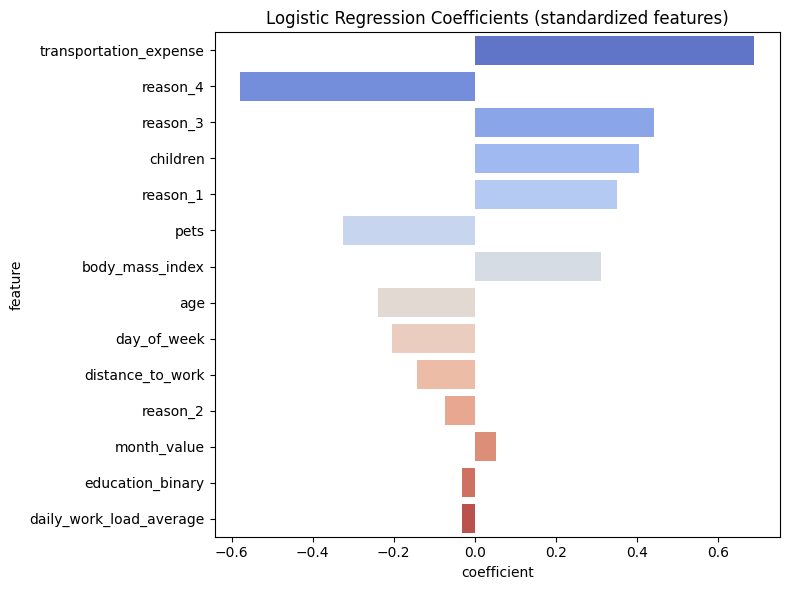

,feature,coefficient
6,transportation_expense,0.690146
3,reason_4,-0.578642
2,reason_3,0.442709
12,children,0.404671
0,reason_1,0.351887
13,pets,-0.325318
10,body_mass_index,0.311795
8,age,-0.237577
5,day_of_week,-0.202851
7,distance_to_work,-0.141172


In [14]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x='coefficient', y='feature', hue='feature', legend=False, palette='coolwarm')
plt.title("Logistic Regression Coefficients (standardized features)")
plt.tight_layout()
plt.savefig('../reports/figures/logreg_coefficients.png', dpi=150)
plt.show()

coef_df

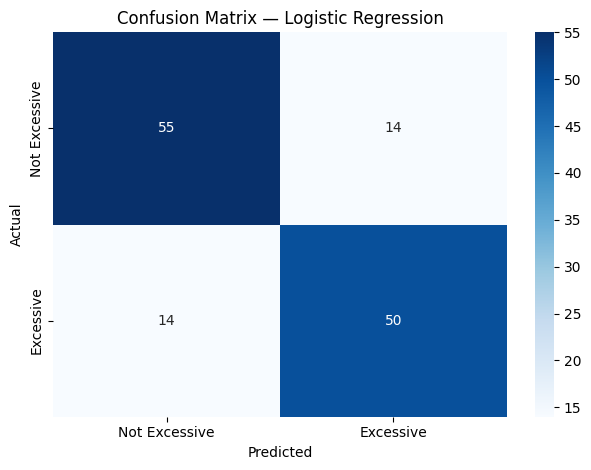

In [15]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Excessive', 'Excessive'],
            yticklabels=['Not Excessive', 'Excessive'])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_logreg.png', dpi=150)
plt.show()

In [16]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_scaled, y_train)

y_pred_gb = gb.predict(X_test_scaled)
y_proba_gb = gb.predict_proba(X_test_scaled)[:, 1]

print("=== Gradient Boosting ===")
print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_gb))

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.77      0.72      0.75        69
           1       0.72      0.77      0.74        64

    accuracy                           0.74       133
   macro avg       0.74      0.75      0.74       133
weighted avg       0.75      0.74      0.74       133

ROC-AUC: 0.8284646739130433


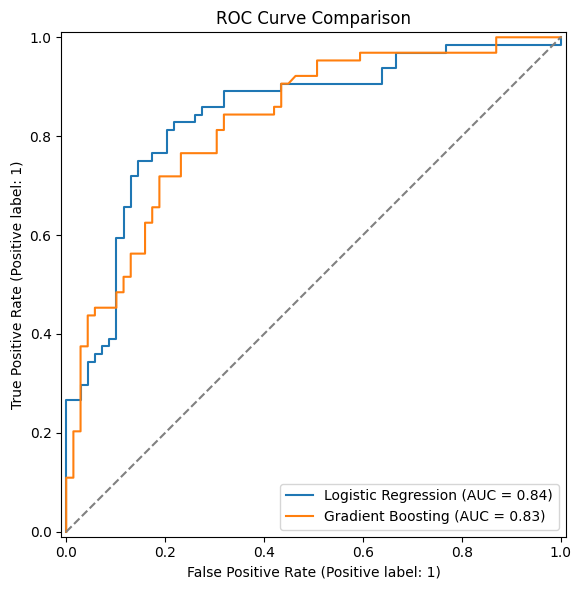

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_gb, name="Gradient Boosting", ax=ax)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.savefig('../reports/figures/roc_comparison.png', dpi=150)
plt.show()

In [18]:
import os
os.makedirs('../models', exist_ok=True)

with open('../models/model.pkl', 'wb') as f:
    pickle.dump(log_reg, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Saved model.pkl and scaler.pkl to ../models/")

Saved model.pkl and scaler.pkl to ../models/


## Modeling Summary
- Primary/reporting model: Logistic Regression — ROC-AUC 0.844 on the held-out test set
  (5-fold CV mean: 0.78, std 0.039). Accuracy 79%, balanced precision/recall (~0.78-0.80)
  across both classes — appropriate given the near-50/50 target split.
- Comparison model: Gradient Boosting — ROC-AUC 0.828, slightly underperforming logistic
  regression on this dataset. This supports using the interpretable model as primary: no
  predictive performance is sacrificed for explainability.
- Top risk drivers (standardized coefficients): transportation_expense (strongest positive
  driver), reason_4 (negative — associated with lower risk), reason_3 (positive driver),
  children (positive driver).
- Limitation: the gap between test-set ROC-AUC (0.844) and CV mean (0.78) reflects some
  variance across folds, likely due to the small dataset size (662 rows) — worth noting
  as a constraint rather than treating the single test-set score as definitive.
- Saved artifacts: model.pkl, scaler.pkl — loaded by the FastAPI scoring service and the
  Kafka consumer in later phases.

In [19]:
import sys
sys.path.append('../src')
from model.absenteeism_model import AbsenteeismModel

scorer = AbsenteeismModel(
    model_path='../models/model.pkl',
    scaler_path='../models/scaler.pkl'
)

# Use a real row from your test set as a sanity check
sample = X_test.iloc[0].to_dict()
print(sample)
print(scorer.predict_single(sample))

# Compare against the original model's prediction for the same row to confirm they match
print("Original model prediction:", y_pred_lr[0], "Original probability:", y_proba_lr[0])

{'reason_1': 0.0, 'reason_2': 0.0, 'reason_3': 0.0, 'reason_4': 1.0, 'month_value': 10.0, 'day_of_week': 4.0, 'transportation_expense': 179.0, 'distance_to_work': 51.0, 'age': 38.0, 'daily_work_load_average': 253.465, 'body_mass_index': 31.0, 'education_binary': 0.0, 'children': 0.0, 'pets': 0.0}
{'excessive_absenteeism_risk': 0, 'risk_probability': 0.214}
Original model prediction: 0 Original probability: 0.2140454506110651
